In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle
import scipy.optimize

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("/home/sak0914/who-analysis/data/freschi2020_SNP_scheme.tsv", sep="\t")

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")
df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")

print(df_rif.shape, df_mxf.shape)
print(df_rif_val.shape, df_mxf_val.shape)

(9137, 19) (7269, 19)
(1406, 17) (1300, 17)


# Replicates Evaluation

Plot validation loss for the 10 bootstrapped replicates and the actual model on top. 

In [2]:
def plot_histories(path, rep_CV=False, binary=False, patience_epochs=25, saveName=False):
        
    if binary:
        prefix = "binary_"
    else:
        prefix = ""
        
    if rep_CV:
        middle_part = "cv"
    else:
        middle_part = "bs"
        
    histories = pd.read_csv(os.path.join(path, f"bootstrapping/{prefix}history_{middle_part}_replicates.csv"))
    history = pd.read_csv(os.path.join(path, f"{prefix}history.csv"))
    history = history.iloc[:-patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    for col in histories.columns:
        single_rep = histories[[col]]
        single_rep = single_rep.loc[~pd.isnull(single_rep[col])].reset_index(drop=True)
        single_rep = single_rep.iloc[:-patience_epochs, :]
        
        plt.plot(single_rep.index.values + 1, single_rep[col], color="lightgray")

    # plt.plot(histories.index + 1, histories.mean(axis=1), color="red", linewidth=1.5)
    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)

    plt.xlabel("Epoch", fontsize=12)
    plot_title = "Validation Loss" + " for " + os.path.basename(path)
    plt.title(plot_title, fontsize=14)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

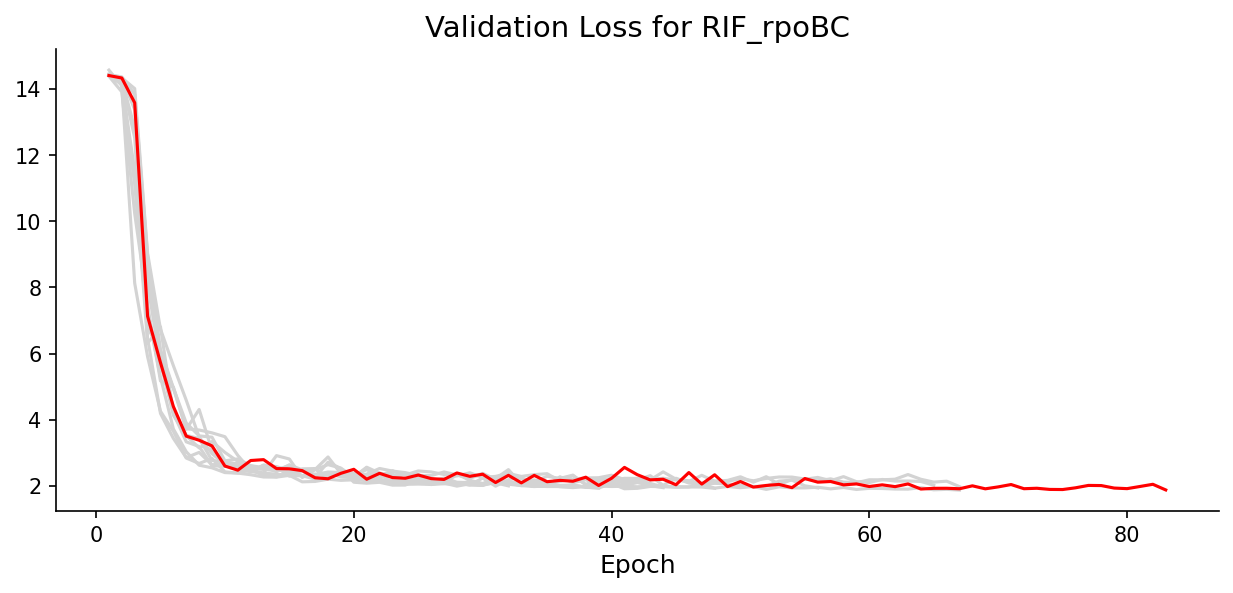

In [65]:
plot_histories(os.path.join(results_path, "RIF_rpoBC"), rep_CV=False, binary=False, patience_epochs=25, saveName="Rifampicin/bootstrap_reps.png")

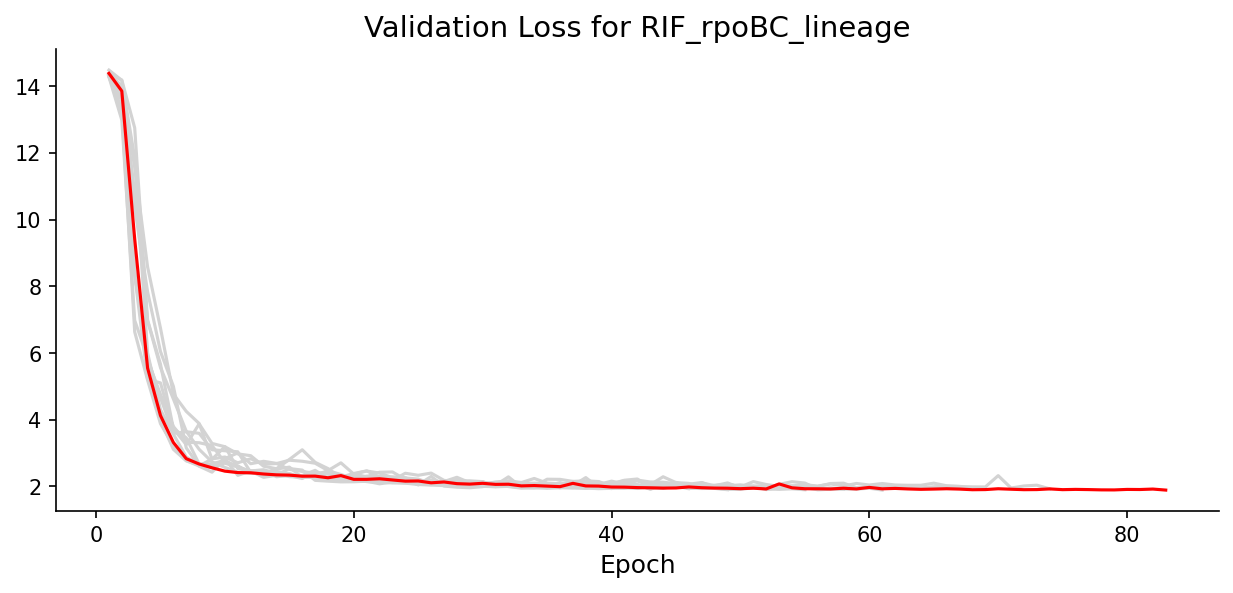

In [56]:
plot_histories(os.path.join(results_path, "RIF_rpoBC_lineage"), rep_CV=False, binary=False, patience_epochs=25)

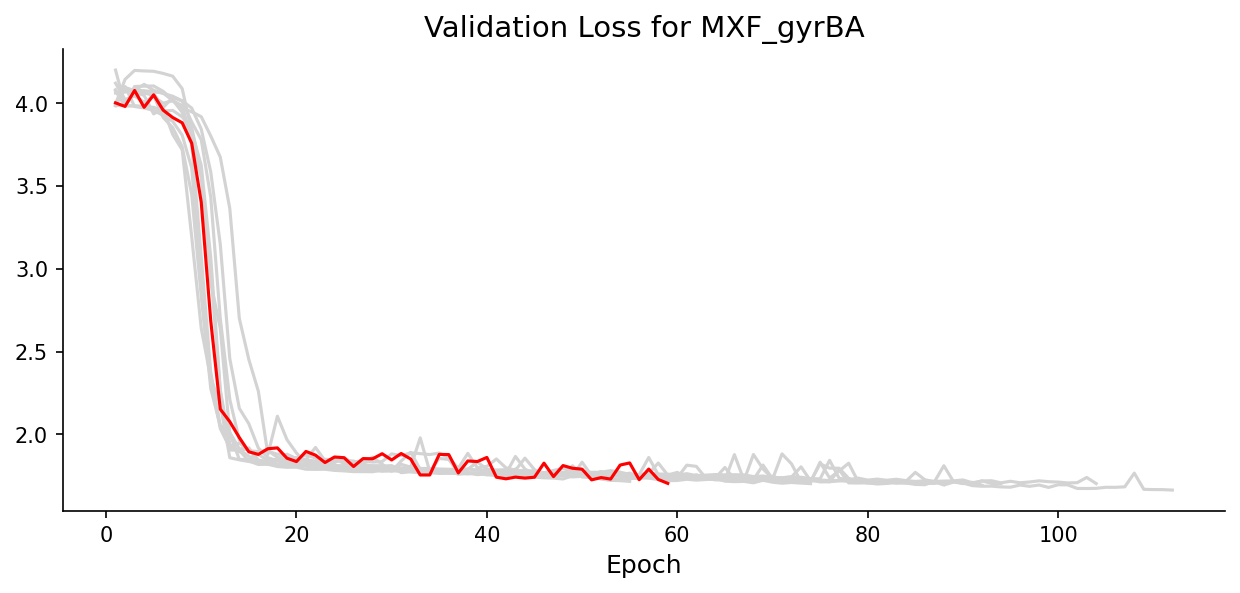

In [57]:
plot_histories(os.path.join(results_path, "MXF_gyrBA"), rep_CV=False, binary=False, patience_epochs=25)

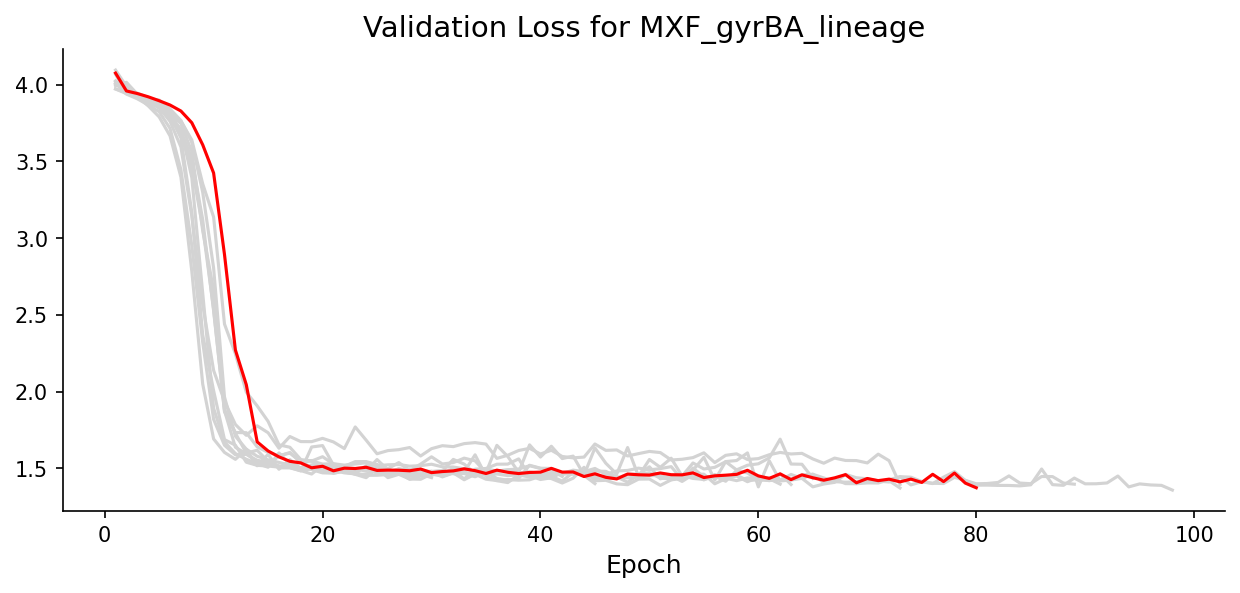

In [58]:
plot_histories(os.path.join(results_path, "MXF_gyrBA_lineage"), rep_CV=False, binary=False, patience_epochs=25)

# Analyze quantitative CNN

In [4]:
def binary_model_analysis(path, drug, cc, num_loci, lineage=0, cv=True, plot=True, patience=25):
    
    history = pd.read_csv(os.path.join(path, "binary_history.csv"))
    pred = pd.read_csv(os.path.join(path, "binary_test_predictions.csv"))
    
    if patience != 0:
        history = history.iloc[:-patience, :]

    print(f"{len(pred)} points in validation set")
    print(f"Trained CNN for {len(history)} epochs")
    
    if plot:
        fig, ax = plt.subplots(figsize=(4, 2))

        plt.plot(history.index.values+1, history["val_loss"].values, label="Loss")
        plt.title("Validation Loss", fontsize=14)
        #plt.xlim(0, stop_epoch)

        sns.despine()
        plt.xlabel("Epoch", fontsize=10)
    
    summary_df = pd.DataFrame({"Drug": drug,
                               "Model": "CNN",
                               "Num_Loci": num_loci,
                              }, index=[0])
    
    summary_df["Num_Loci"] = "Binary"
    summary_df["CV"] = 0
    summary_df["Lineage"] = lineage
    summary_metrics_df = compute_binary_metrics(pred["y_pred_label"].values, pred["y_test"].values, cc, binarize=False)
    summary_df = pd.concat([summary_df, summary_metrics_df], axis=1)
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "binary_val_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = "Binary"
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df
    

def quant_model_analysis(path, drug, cc, df_phenos, num_loci=1, lineage=0, cv=True, plot=True, patience=25, savefName=None):
    
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    history = pd.read_csv(os.path.join(path, "history.csv"))
    
#     if log_midpoint:
#         y = []
#         for _, row in df_phenos.query("category=='original_test_set'").iterrows():

#             # the upper bounds for the highest MICs have been changed to be a very large number, so doesn't make sense to 
#             # take the midpoint of the lower and upper bounds. So log-transform the lower bound
#             if ">" in row[drug]:
#                 y.append(np.log2(row[f"{drug}_lower_bound"]))
#             # can't log-transform the lower bound of the lowest MICs (which is 0), so log-transform the upper bound
#             elif "<=" in row[drug] or "<" in row[drug]:
#                 y.append(np.log2(row[f"{drug}_upper_bound"]))
#             else:
#                 y.append(np.mean([np.log2(row[f"{drug}_lower_bound"]), np.log2(row[f"{drug}_upper_bound"])]))

#             # the loss functions will not penalize predictions below the lowest MICs (unless the predicted MIC is negative) or above the highest MICs

#         y = np.array(y)
#         assert np.inf not in y
#         assert -np.inf not in y
        
#         pred_df["y_test"] = y
    
    if patience != 0:
        last_epoch = len(history) - patience
    else:
        last_epoch = len(history)
    
    print(f"{len(pred_df)} points in validation set")
    print(f"Trained CNN for {last_epoch} epochs")
    
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))

        ax[0].plot(history.index.values+1, history["val_loss"].values, label="Loss")
        ax[0].set_title("Validation Loss", fontsize=14)
        ax[0].set_xlabel("Epoch", fontsize=10)
        ax[0].axvline(x=last_epoch, color="black", linestyle="dashed")
        
        values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=pred_df,
            x="y_pred",
            y="y_test",
            c=kernel,
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax[1]
        )

        max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
        min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

#         ax[1].set_xscale(matplotlib.scale.LogScale(ax[1], base=2))
#         ax[1].set_yscale(matplotlib.scale.LogScale(ax[1], base=2))
        
        ax[1].set_xlabel("Predicted MIC (µg/mL)")
        ax[1].set_ylabel("Actual MIC (µg/mL)")
        ax[1].set_xlim(min_val, max_val)
        ax[1].set_ylim(min_val, max_val)
        
        tick_labels = []

        for num in np.exp2(ax[1].get_xticks()):
            if num < 1:
                tick_labels.append(str(np.round(num, 2)))
            else:
                tick_labels.append(str(int(num)))
        
        ax[1].set_xticks(ticks=ax[1].get_xticks(), labels=tick_labels)
        ax[1].set_yticks(ticks=ax[1].get_yticks(), labels=tick_labels)
        
        ax[1].set_xlabel("\nPredicted MIC (µg/mL)", fontsize=9)
        ax[1].set_ylabel("Actual MIC (µg/mL)\n", fontsize=9)

        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
    
        sns.despine()
        plt.tight_layout()
        
        if savefName is not None:
            plt.savefig(savefName, dpi=300)
        else:
            plt.show()
        
        
    summary_df = pd.read_csv(os.path.join(path, "cnn_results.csv"))
    summary_df["CV"] = 0
    summary_df["Lineage"] = lineage
    
    if cv:
        cv_results = pd.read_csv(os.path.join(path, "bootstrapping/bs_results.csv"))
        cv_results["CV"] = np.arange(len(cv_results))+1
        cv_results["Num_Loci"] = num_loci
        cv_results["Lineage"] = lineage
        return pd.concat([summary_df, cv_results])
    else:
        return summary_df

# Rifampicin

In [74]:
def plot_ridge_results(path, savefName=None):
    
    pred_df = pd.read_csv(os.path.join(path, "ridge/test_predictions.csv"))
                          
    fig, ax = plt.subplots(figsize=(5, 4))
    
    values = np.vstack([pred_df["y_pred"], pred_df["y_test"]])
    kernel = st.gaussian_kde(values)(values)

    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="y_test",
        c=kernel,
        cmap="Blues",
        linewidth=0.25,
        edgecolor="lightgray",
        ax=ax
    )
    
    max_val = np.max([pred_df.y_pred, pred_df.y_test]) * 1.1
    min_val = np.min([pred_df.y_pred, pred_df.y_test]) * 1.1

    ax.set_xlabel("\nPredicted MIC (µg/mL)", fontsize=9)
    ax.set_ylabel("Actual MIC (µg/mL)", fontsize=9)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    # ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
#     max_log2 = 10
#     ax.set_xticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
#     ax.set_yticks(ticks=np.concatenate([np.array([0]), np.linspace(0, max_log2, max_log2+1)]), labels=np.concatenate([np.array([0]), np.exp2(np.linspace(0, max_log2, max_log2+1))]))
    
    # smallest_power = -6
    # largest_power = 3
    smallest_power = np.floor(np.min([pred_df.y_pred, pred_df.y_test]))
    largest_power = np.ceil(np.max([pred_df.y_pred, pred_df.y_test]))
    smallest_power = -8
    
    tick_labels = []

    for num in np.exp2(np.linspace(smallest_power, largest_power, 11)):
        if num < 1:
            tick_labels.append(str(np.round(num, 2)))
        else:
            tick_labels.append(str(int(num)))
        
    ax.set_xticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    ax.set_yticks(ticks=np.linspace(smallest_power, largest_power, 11), labels=tick_labels)
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    sns.despine()
    plt.tight_layout()
    
    if savefName is not None:
        plt.savefig(savefName, dpi=300)
    else:
        plt.show()
        
        
        
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    assert sum(~pd.isnull(x1.query("CV>0")[var].values)) == sum(~pd.isnull(x2.query("CV>0")[var].values))
    #return st.mannwhitneyu(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
    return st.mannwhitneyu(x1.query("CV>0")[var], x2.query("CV>0")[var], alternative=alt)[1]
        
        
def compare_two_models(model_1, model_2, test_variables=["Binned_MSE", "Spearman", "Within_1Bin", "Sensitivity", "Specificity", "Balanced_Acc"]):
    '''
    Directionality is important. Put the one hypothesized to be better FIRST
    '''
    # lineage does not significantly improve RIF prediction
    for var in test_variables:

        pval = test_for_significance(model_1, model_2, var, alt="two-sided")

        # if the two-sided test is significant, then try one-sided, based on the variable
        if pval < 0.05:

            if "MAE" in var or "MSE" in var:
                alt = "less"
            else:
                alt = "greater"
        
            pval = test_for_significance(model_1, model_2, var, alt=alt)
            
            if pval < 0.05:
                print(f"{var}, pval = {pval}")
        else:
            print(f"{var}, ns: pval = {pval}")

1827 points in validation set
Trained CNN for 83 epochs
1827 points in validation set
Trained CNN for 83 epochs


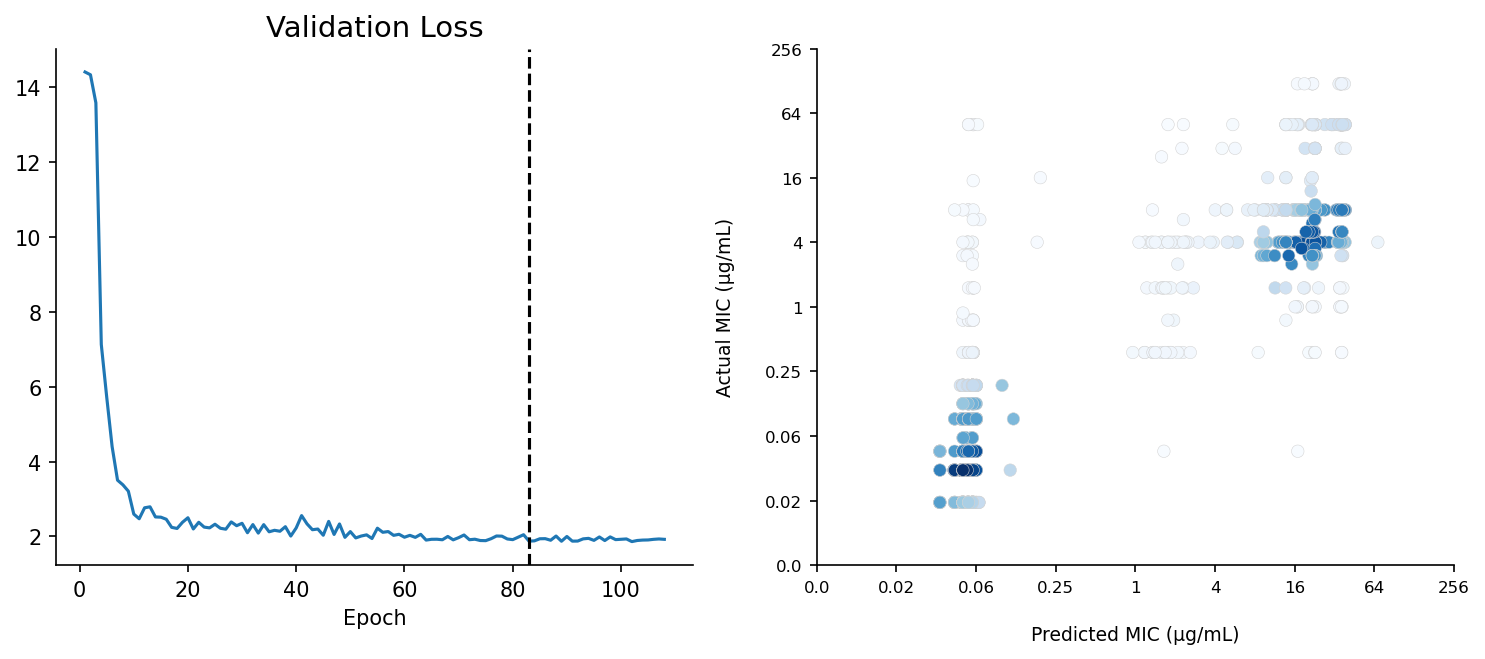

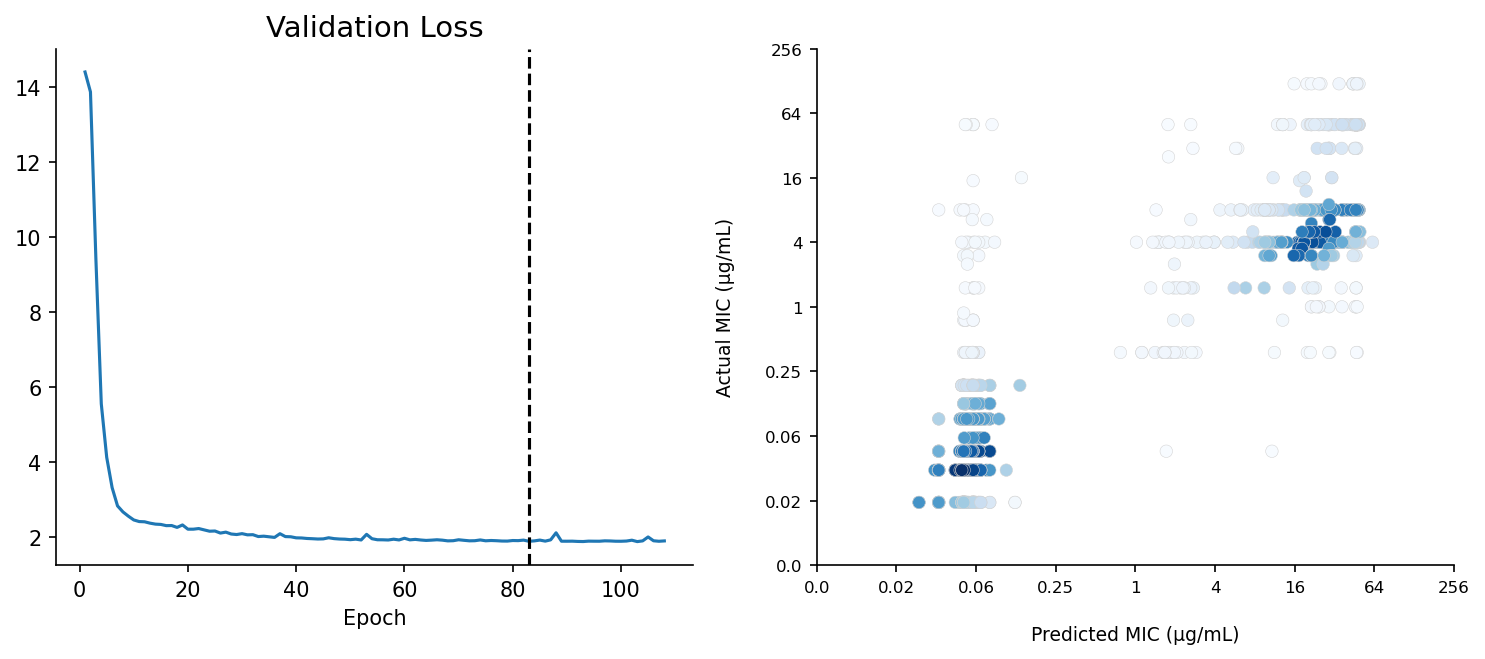

In [6]:
path_rif = "RIF_rpoBC"

rif_CNN = quant_model_analysis(os.path.join(results_path, f"{path_rif}"), "RIF", 0.5, df_rif, num_loci=1, lineage=0, patience=25, cv=True, plot=True, savefName="Rifampicin/CNN_predictions.png")
rif_Reg = pd.read_csv(os.path.join(results_path, path_rif, "ridge", "ridge_results.csv"))

rif_lineage_CNN = quant_model_analysis(os.path.join(results_path, f"{path_rif}_lineage"), "RIF", 0.5, df_rif, num_loci=1, lineage=1, patience=25, cv=True, plot=True)
rif_lineage_Reg = pd.read_csv(os.path.join(results_path, f"{path_rif}_lineage", "ridge", "ridge_results.csv"))

# combine all results dataframes for plotting
rif_compare = pd.concat([
                        #rif_binary_CNN, rif_binary_Reg,
                       # rif_lineage_binary_CNN, rif_lineage_binary_Reg,
                       rif_CNN, rif_Reg, 
                       rif_lineage_CNN, rif_lineage_Reg
                      ], axis=0)

rif_compare["Group"] = [1]*11 + [2]*11 + [3]*11 + [4]*11
rif_compare["Without_1Bin"] = 1 - rif_compare["Within_1Bin"]

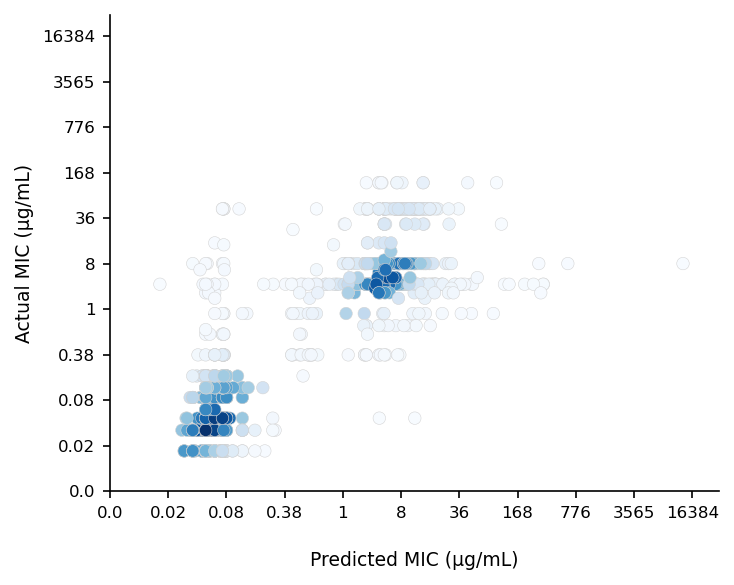

In [10]:
plot_ridge_results(os.path.join(results_path, f"{path_rif}"), savefName="Rifampicin/ridge_predictions.png")
# plot_ridge_results(os.path.join(results_path, f"{path_rif}_lineage"))

In [4]:
def plot_residuals(path, pred_col="y_pred", actual_col="y_test"):
    
    pred_df = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    pred_df["residual"] = pred_df[actual_col] - pred_df[pred_col]
    
    sns.residplot(data=pred_df, x=actual_col, y="residual")
    plt.xlabel("Test Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    sns.despine()
    plt.show()

In [16]:
# plot_residuals(os.path.join(results_path, path_rif, "ridge"))

In [17]:
# plot_residuals(os.path.join(results_path, path_rif))

In [18]:
# plot_residuals(os.path.join(results_path, path_mxf))

In [75]:
compare_two_models(rif_CNN, rif_Reg)

Binned_MSE, pval = 9.133589555477501e-05
Spearman, pval = 0.00029141997158963715
Within_1Bin, pval = 9.082557304573249e-05
Sensitivity, pval = 7.692317130286052e-05
Balanced_Acc, pval = 8.583754358560144e-05


In [76]:
# lineage doesn't significantly affect CNN
compare_two_models(rif_lineage_CNN, rif_CNN)

Binned_MSE, ns: pval = 0.3074894566186813
Spearman, ns: pval = 0.9698499769931556
Within_1Bin, ns: pval = 0.622652636570054
Sensitivity, ns: pval = 0.8343409086886475
Specificity, ns: pval = 1.0
Balanced_Acc, ns: pval = 0.906592518273294


In [78]:
# lineage doesn't significantly affect regression
compare_two_models(rif_lineage_Reg, rif_Reg)

Binned_MSE, ns: pval = 0.3447042220069576
Spearman, ns: pval = 0.8501067391385259
Within_1Bin, ns: pval = 0.34434119233838356
Sensitivity, ns: pval = 0.9092106703797972
Specificity, ns: pval = 0.42207211685289403
Balanced_Acc, ns: pval = 0.36380450713550716


In [56]:
def plot_model_results(df, variable_lst, tick_labels, sharey, meanLine_width=0.3, lower_bounds=None, upper_bounds=None, savefName=None):
    
    if len(variable_lst) <= 3:
        col_wrap = None
    else:
        col_wrap =2
    
    plot_df = df.query("CV > 0").melt(id_vars=["Model", "Lineage"], value_vars=variable_lst)
    plot_df["Model"] = plot_df["Model"].replace("LinReg", "Regression")
    plot_df["Model"] = plot_df["Model"].replace("LogReg", "Regression")
    
    palette = sns.color_palette("Set2").as_hex()
    color_dict = dict(zip(plot_df.Model.unique(), palette[:len(plot_df.Model.unique())]))
        
    g = sns.catplot(data=plot_df, 
                    x="Lineage", 
                    y="value", 
                    hue="Model", 
                    col="variable", 
                    col_order=variable_lst,
                    col_wrap=col_wrap,
                    hue_order=["Regression", "CNN"], 
                    kind="strip", 
                    dodge=True,
                    aspect=0.9, 
                    height=4, 
                    linewidth=0.5,
                    palette=color_dict,
                    sharex=False,
                    sharey=sharey,
                    legend_out=True
                   )

    for i, (col_name, ax) in enumerate(g.axes_dict.items()):

        sns.pointplot(data=plot_df.query("variable == @col_name"),
                      x="Lineage", 
                      y="value", 
                      hue="Model", 
                      hue_order=["Regression", "CNN"], 
                      palette=color_dict, 
                      dodge=0.4, 
                      join=False, 
                      ci=0, 
                      errwidth=2, # thickness
                      capsize=meanLine_width,  # height
                      scale=0, 
                      ax=ax
                     )

        if not sharey:
            if type(lower_bounds) == np.ndarray or type(lower_bounds) == list:
                ax.set_ylim(lower_bounds[i], upper_bounds[i])

        # don't add another legend from the pointplot function
        ax.get_legend().remove()


    # put a box around the legend
    sns.move_legend(g, title="", loc="center right", frameon=True, fontsize="small")

    g.set(xlabel=None, ylabel=None)
    g.set_titles(template='{col_name}\n')
    g.set_xticklabels(tick_labels)

    if sharey:
        if lower_bound is not None and upper_bound is not None:
            g.set(ylim=(lower_bound, upper_bound))
    
    sns.despine()
    # plt.tight_layout()
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)

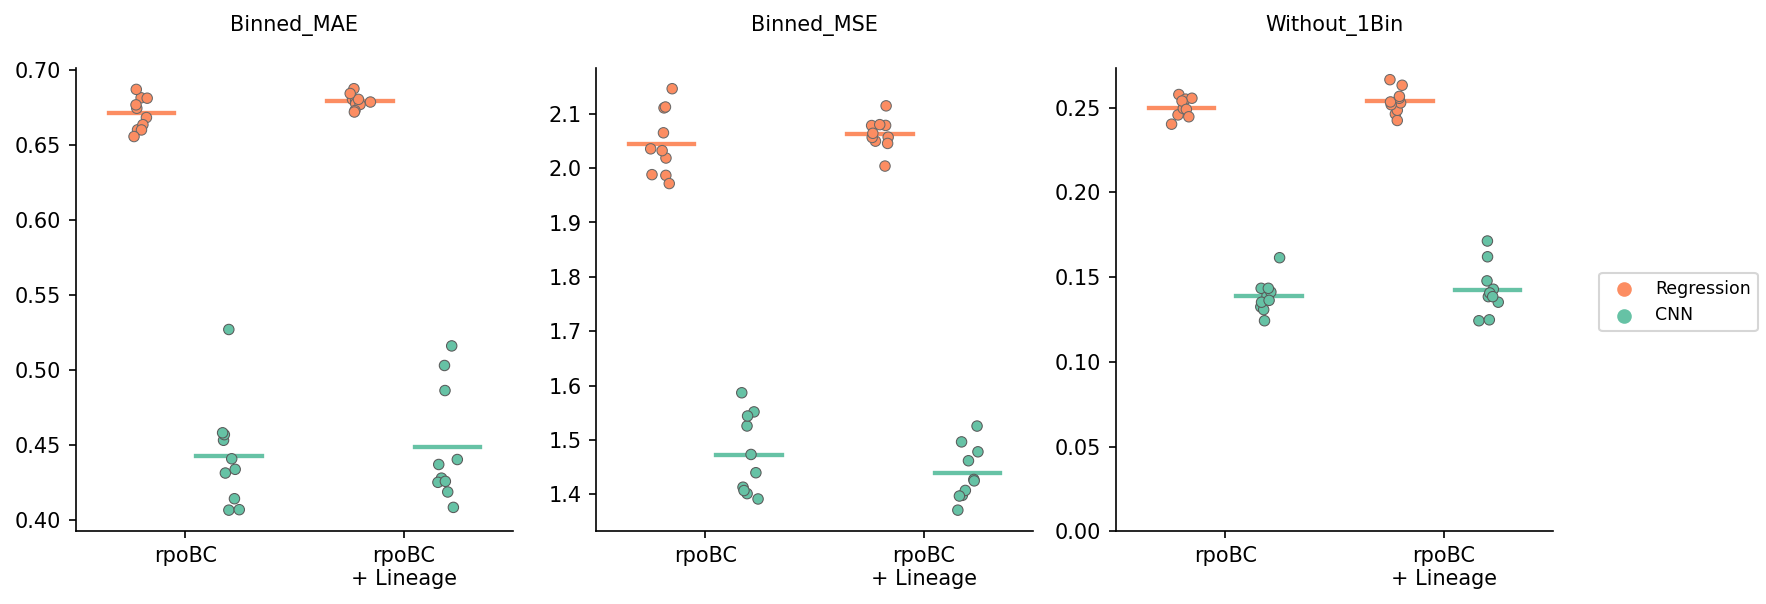

In [9]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_1Bin"]

plot_model_results(rif_compare, variable_lst, ["rpoBC", "rpoBC\n+ Lineage"], sharey=False, meanLine_width=0.3, 
                   lower_bounds=[None, None, 0], upper_bounds=[None, None, None], 
                   savefName="Rifampicin/quantitative_metrics.png"
                  )

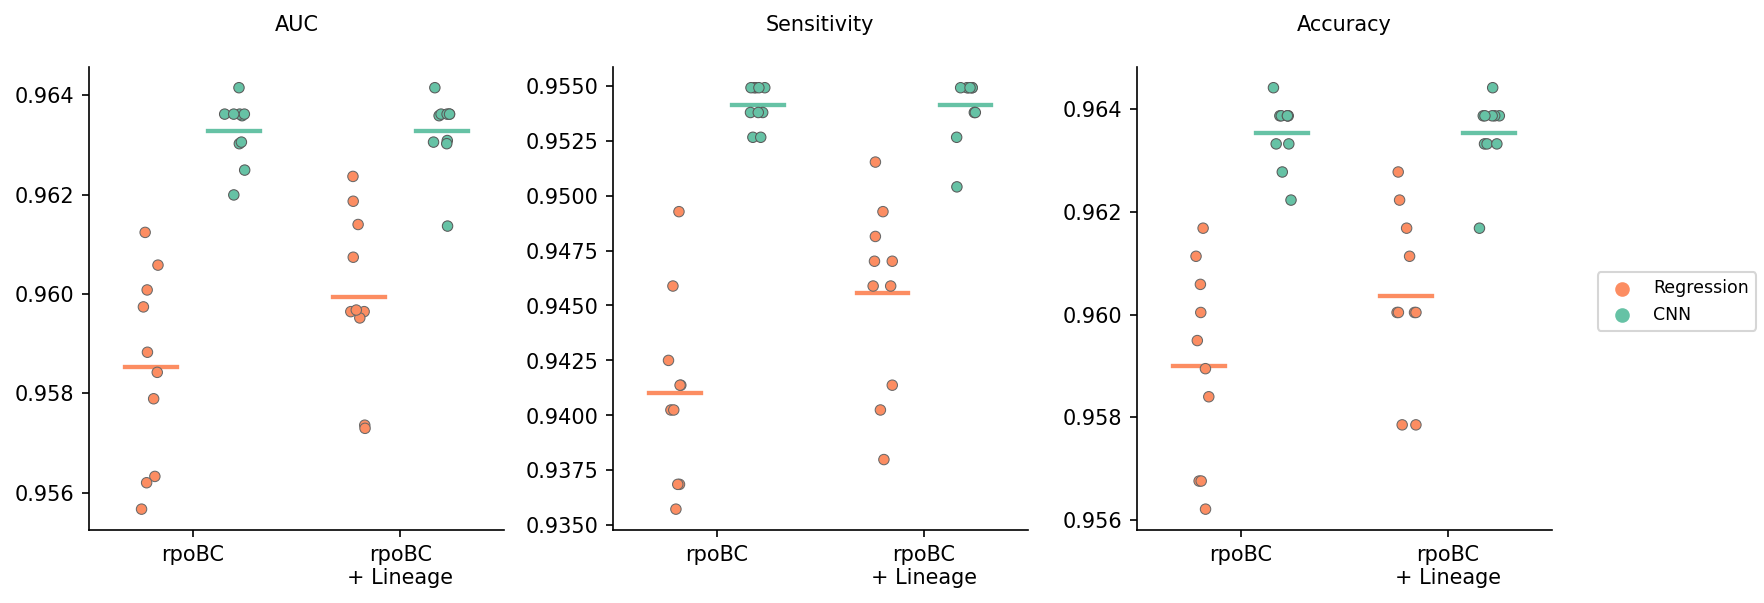

In [18]:
variable_lst = ["Sensitivity", "Specificity", "Accuracy"]
# variable_lst = ["Sensitivity"]
plot_model_results(rif_compare, variable_lst, ["rpoBC", "rpoBC\n+ Lineage"], sharey=False, meanLine_width=0.25, 
                   #lower_bound=[0.95, 0.92, 0.95], upper_bound=[0.97, 0.97, 0.97],
                   #savefName="Rifampicin/quant_binary_metrics.png"
                  )

## Isolates with reference H37Rv sequence but are predicted resistant

In [126]:
set(df_pred.query("y_test_exp > 0.5").Isolate) - set(RIF_isolate_variants.Isolate)

{'ERR4797746', 'ERR4811342', 'ERR4829856', 'Peru2938', 'Peru4616'}

In [88]:
for i, row in RIF_isolate_variants.iterrows():
    
    if row["EFFECT"] in ['upstream_gene_variant', 'synonymous_variant']:
        RIF_isolate_variants.loc[i, "mutation"] = row["GENE"] + "_" + row["NUC"]
    else:
        RIF_isolate_variants.loc[i, "mutation"] = row["GENE"] + "_" + row["PROT"]
        
# separate over- and underpredicted isolates
binary_underpred = RIF_isolate_variants.merge(df_pred[["Isolate", "y_pred_exp", "y_test_exp"]].query('y_pred_exp < 0.5 & y_test_exp > 0.5'), how="inner")
binary_overpred = RIF_isolate_variants.merge(df_pred[["Isolate", "y_pred_exp", "y_test_exp"]].query('y_pred_exp > 0.5 & y_test_exp < 0.5'), how="inner")

assert len(binary_underpred.query("mutation == 'rpoB_p.Ser450Leu'")) == 0
assert len(set(binary_underpred.Isolate).intersection(binary_overpred.Isolate)) == 0
len(binary_underpred.Isolate.unique()), len(binary_overpred.Isolate.unique())

(36, 26)

<Axes: xlabel='lower', ylabel='mae'>

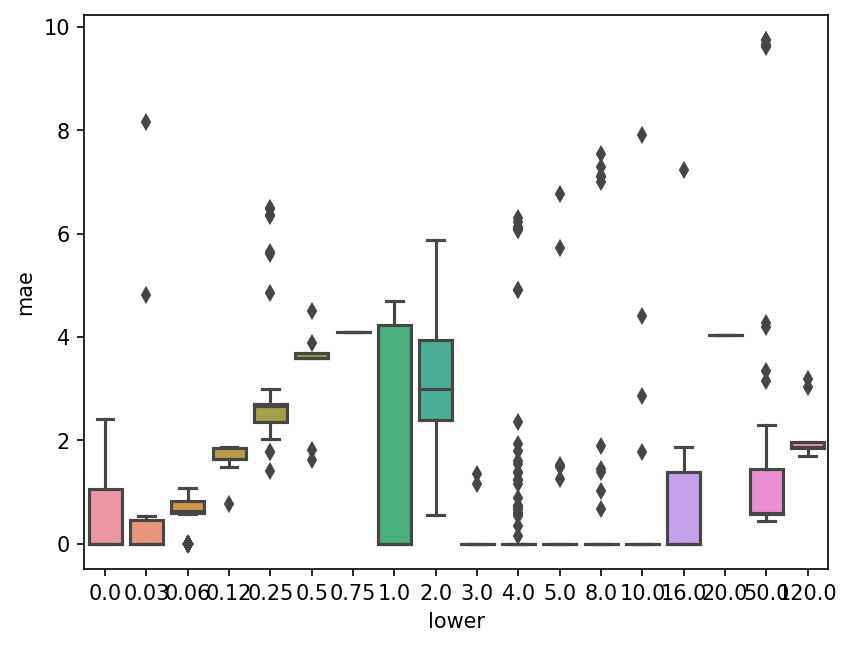

In [ ]:
sns.boxplot(data=df_pred,
            x="lower",
            y="mae"
           )

# Moxifloxacin

1454 points in validation set
Trained CNN for 59 epochs


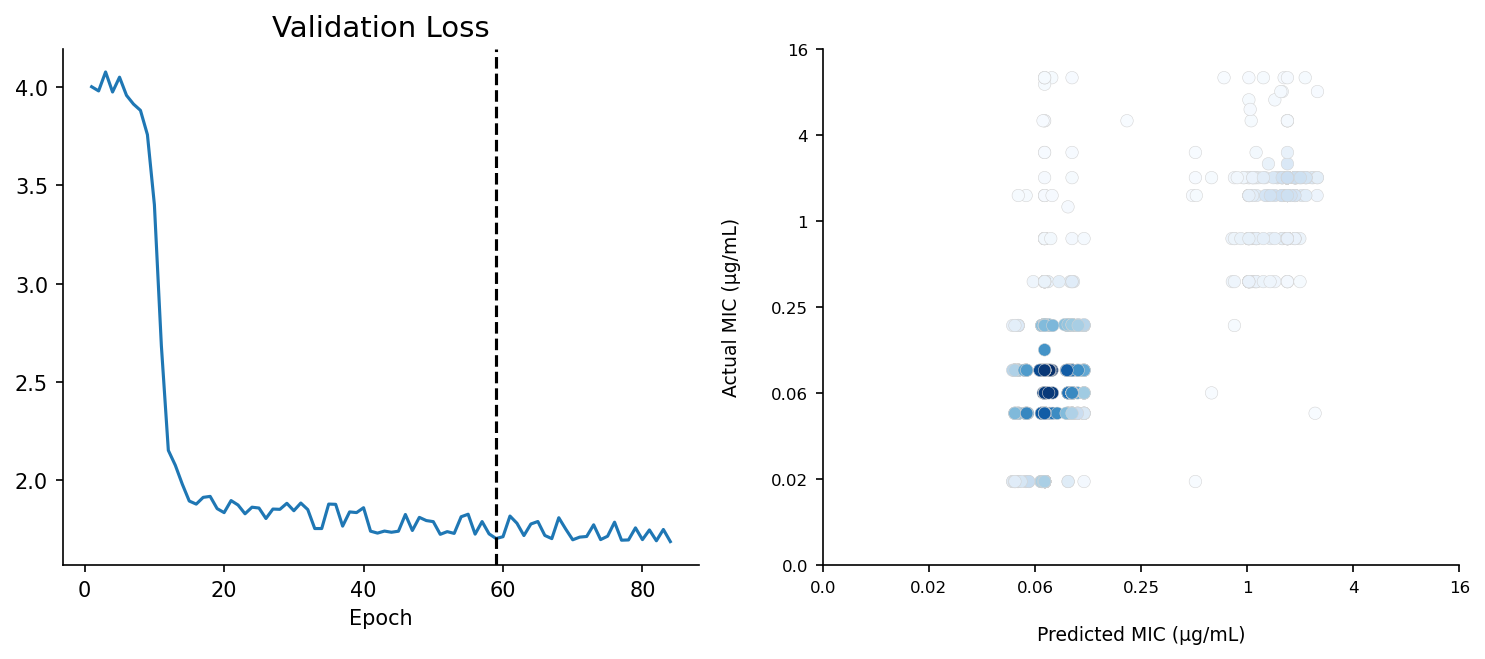

1454 points in validation set
Trained CNN for 80 epochs


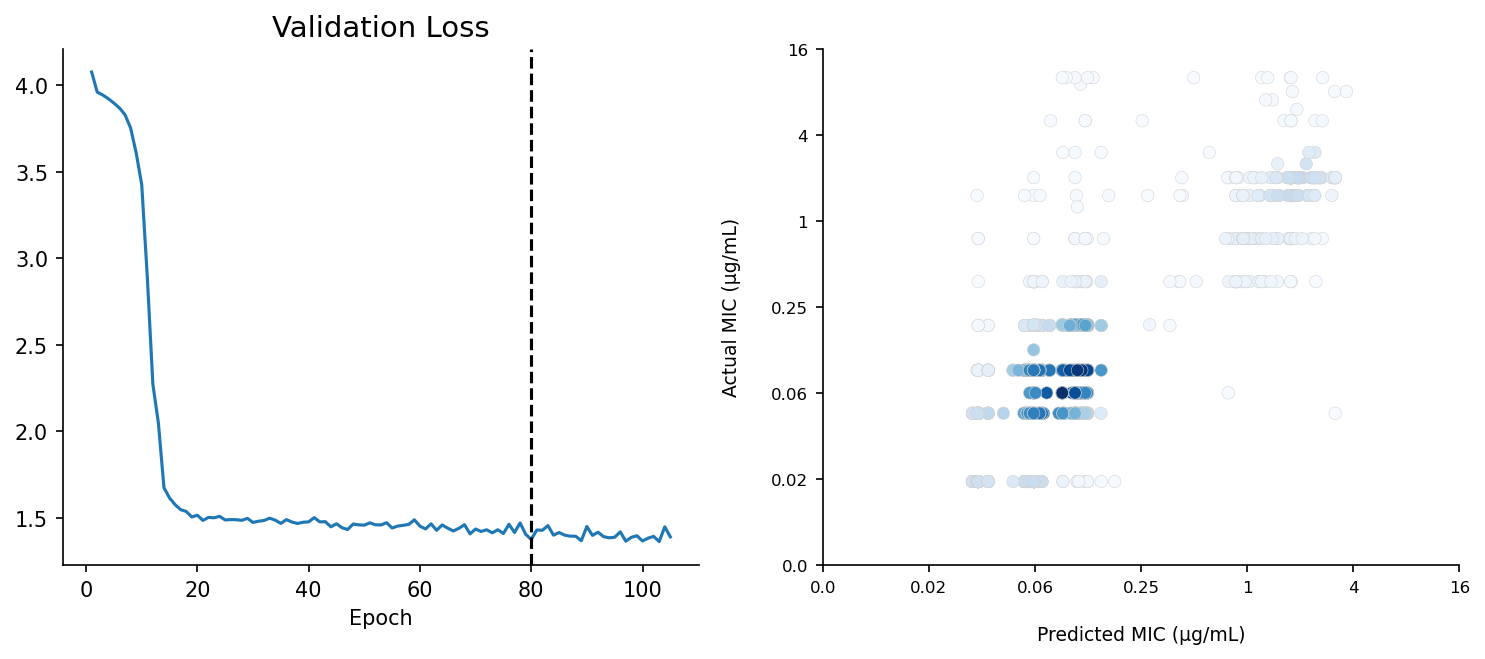

In [12]:
# moxi_gyrBA_binary_CNN = binary_model_analysis(os.path.join(results_path, "MXF_gyrBA"), "MOXI", 0.5, 1, lineage=0, cv=True, plot=False)
# moxi_gyrBA_binary_LogReg = pd.read_csv(os.path.join(results_path, "MXF_gyrBA", "ridge", "binary_ridge_results.csv"))
path_mxf = "MXF_gyrBA"
mxf_CNN = quant_model_analysis(os.path.join(results_path, f"{path_mxf}"), "RIF", 0.5, df_mxf, num_loci=1, lineage=0, patience=25, cv=True, plot=True)
mxf_Reg = pd.read_csv(os.path.join(results_path, path_mxf, "ridge", "ridge_results.csv"))

mxf_lineage_CNN = quant_model_analysis(os.path.join(results_path, f"{path_mxf}_lineage"), "MOXI", 0.5, df_mxf, 1, patience=25, lineage=1, cv=True, plot=True)
mxf_lineage_Reg = pd.read_csv(os.path.join(results_path, f"{path_mxf}_lineage", "ridge", "ridge_results.csv"))

# combine all results dataframes for plotting
mxf_compare = pd.concat([mxf_CNN, mxf_Reg,
                          mxf_lineage_CNN, mxf_lineage_Reg
                        ], axis=0)

mxf_compare["Group"] = [1]*11 + [2]*11 + [3]*11 + [4]*11
mxf_compare["Drug"] = "MXF"
mxf_compare["Without_1Bin"] = 1 - mxf_compare["Within_1Bin"]

In [67]:
rif_num = np.sqrt(rif_Reg.query("CV > 0")["Binned_MSE"]).mean() - np.sqrt(rif_CNN.query("CV > 0")["Binned_MSE"]).mean()
rif_num

0.21686397313848071

In [68]:
rif_denom = np.log2(df_rif["RIF_midpoint"]).std()
rif_denom

3.8114028665763824

In [70]:
rif_num / rif_denom * 100

5.689872751060824

In [71]:
mxf_num = np.sqrt(mxf_Reg.query("CV > 0")["Binned_MSE"]).mean() - np.sqrt(mxf_CNN.query("CV > 0")["Binned_MSE"]).mean()
mxf_num

0.04253766705172102

In [72]:
mxf_denom = np.log2(df_mxf["MXF_midpoint"]).std()
mxf_denom

2.0166051474723705

In [73]:
mxf_num / mxf_denom * 100

2.109370151367415

In [65]:
df_mxf[["MXF_lower_bound", "MXF_midpoint", "MXF_upper_bound"]].drop_duplicates().sort_values("MXF_lower_bound")

,MXF_lower_bound,MXF_midpoint,MXF_upper_bound
7152,0.000,0.1250,0.250
6158,0.000,0.0625,0.125
6186,0.000,0.2500,0.500
145,0.000,0.0150,0.030
8,0.030,0.0450,0.060
0,0.060,0.0900,0.120
2,0.120,0.1850,0.250
6184,0.125,0.3125,0.500
6156,0.125,0.1875,0.250
39,0.250,0.3750,0.500


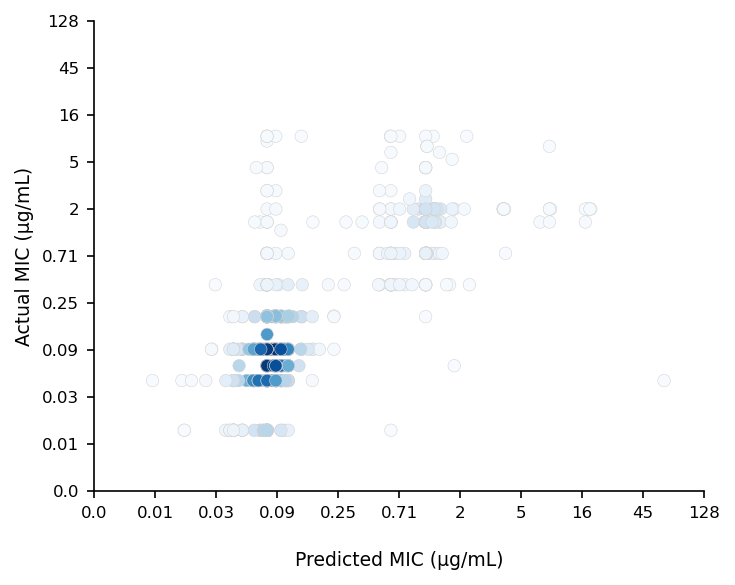

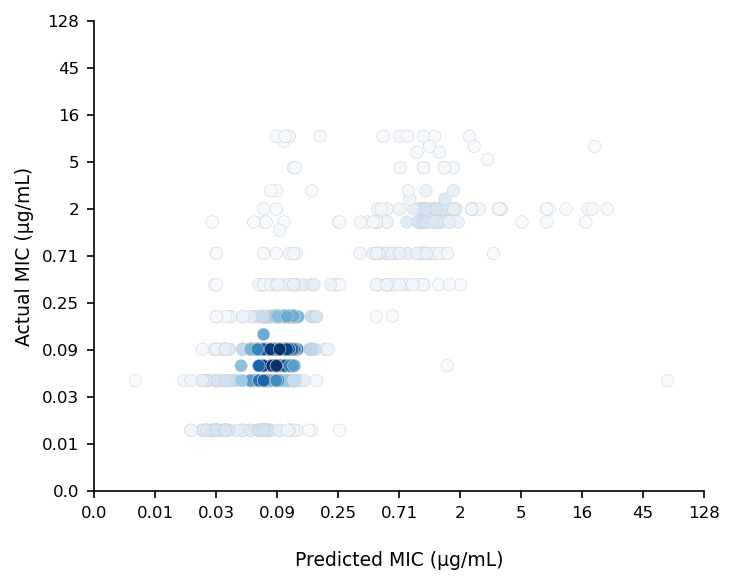

In [66]:
plot_ridge_results(os.path.join(results_path, f"{path_mxf}"))
plot_ridge_results(os.path.join(results_path, f"{path_mxf}_lineage"))

In [82]:
compare_two_models(mxf_CNN, mxf_Reg)

Binned_MSE, pval = 9.133589555477501e-05
Within_1Bin, ns: pval = 0.21108844562718387
Sensitivity, ns: pval = 1.0
Specificity, ns: pval = 0.7192430352461667
Balanced_Acc, ns: pval = 1.0


In [83]:
compare_two_models(mxf_lineage_CNN, mxf_CNN)

Binned_MSE, pval = 9.133589555477501e-05
Spearman, pval = 9.133589555477501e-05
Within_1Bin, ns: pval = 0.9096542252801711
Sensitivity, ns: pval = 0.8773324244767604
Specificity, pval = 9.913108228084419e-05
Balanced_Acc, ns: pval = 0.34343109459056476


In [84]:
compare_two_models(mxf_lineage_Reg, mxf_Reg)

Binned_MSE, pval = 9.133589555477501e-05
Spearman, pval = 9.133589555477501e-05
Within_1Bin, pval = 0.00625567469163966
Specificity, pval = 8.012318266794122e-05


In [85]:
print(test_for_significance(mxf_CNN, mxf_Reg, "Within_1Bin", alt="two-sided"))
print(test_for_significance(mxf_CNN, mxf_lineage_CNN, "Within_1Bin", alt="two-sided"))
print(test_for_significance(mxf_CNN, mxf_lineage_Reg, "Within_1Bin", alt="two-sided"))
print(test_for_significance(mxf_Reg, mxf_lineage_CNN, "Within_1Bin", alt="two-sided"))
print(test_for_significance(mxf_lineage_CNN, mxf_lineage_Reg, "Within_1Bin", alt="two-sided"))
print(test_for_significance(mxf_Reg, mxf_lineage_Reg, "Within_1Bin", alt="two-sided"))

0.21108844562718387
0.9096542252801711
0.0035852853678737984
1.0
0.5707503880581739
0.01251134938327932


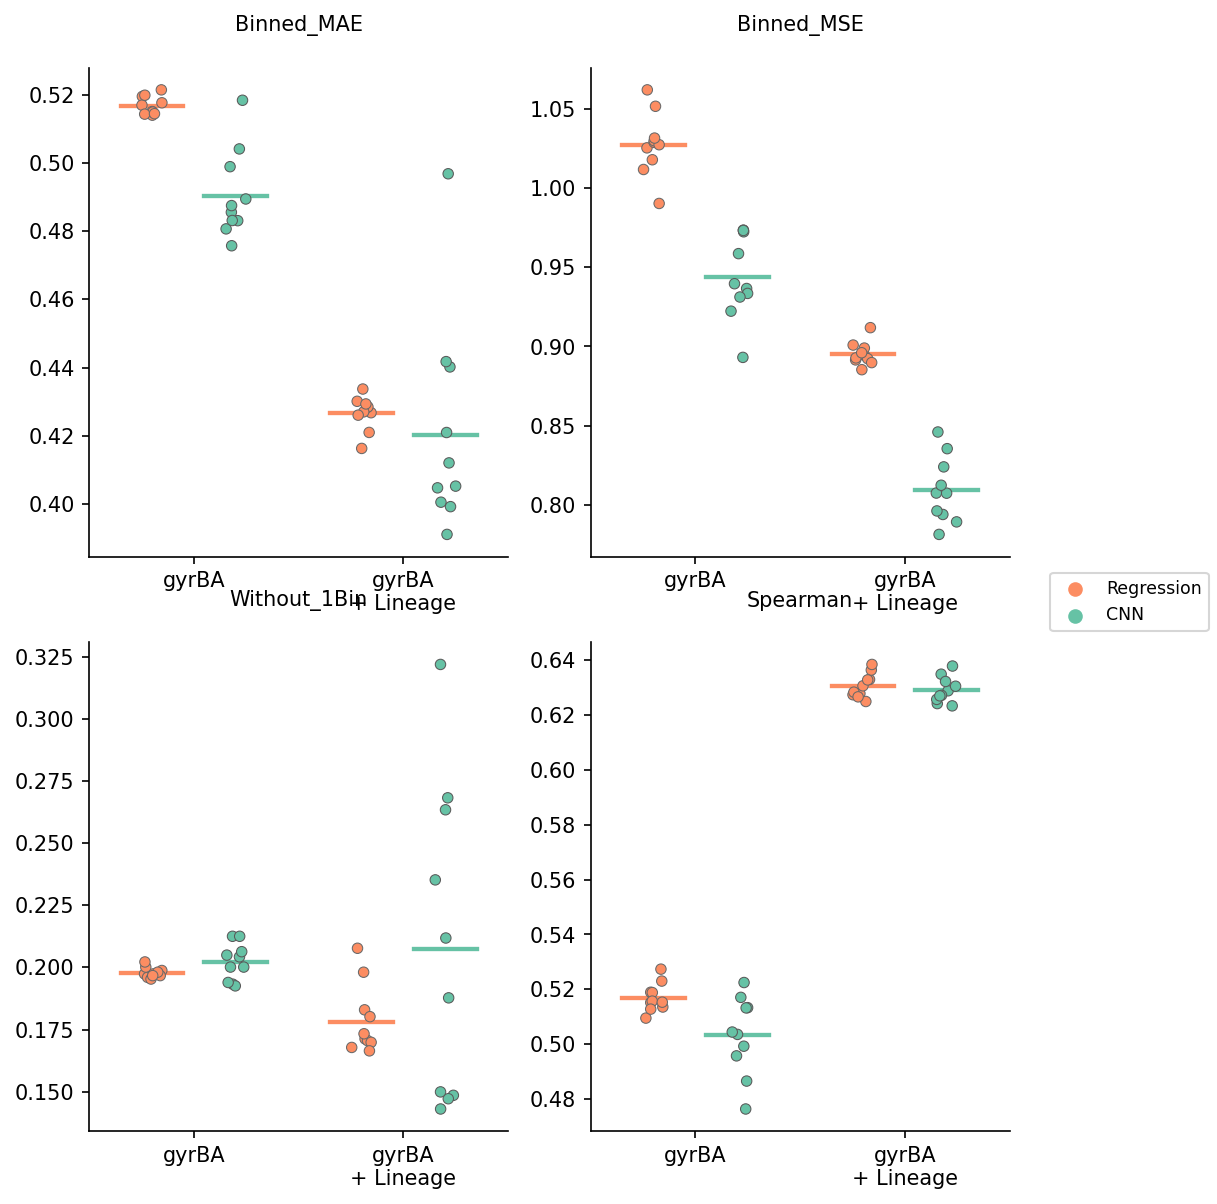

In [37]:
variable_lst = ["Binned_MAE", "Binned_MSE", "Without_1Bin", "Spearman"]
plot_model_results(mxf_compare, variable_lst, ["gyrBA", "gyrBA\n+ Lineage"], sharey=False, meanLine_width=0.3, lower_bounds=None, upper_bounds=None, 
                   #savefName="Moxifloxacin/error_metrics.png"
                  )

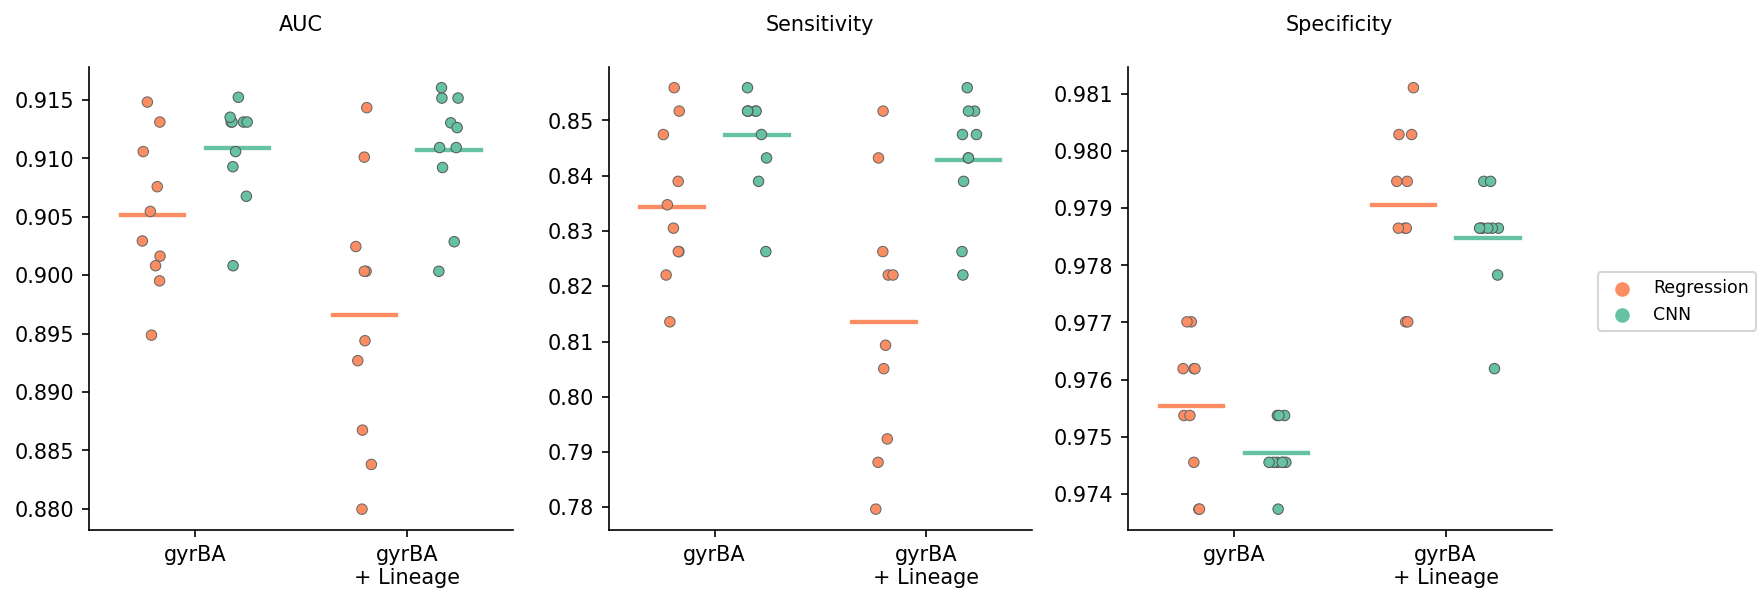

In [20]:
variable_lst = ["Sensitivity", "Specificity", "Accuracy"]
plot_model_results(mxf_compare, variable_lst, ["gyrBA", "gyrBA\n+ Lineage"], sharey=False, meanLine_width=0.3, lower_bound=None, upper_bound=None,
                   #savefName="Moxifloxacin/error_metrics.png"
                  )

# Distribution of Mispredictions

In [27]:
def error_dist(cnn_dir):
    
    path = os.path.join(results_path, cnn_dir)
    pred = pd.read_csv(os.path.join(path, "test_predictions.csv"))
    
    fig, ax = plt.subplots()
    sns.histplot(pred.y_pred - pred.y_test, stat="probability", ax=ax)
    plt.axvline(np.mean(pred.y_pred - pred.y_test), color="black", linestyle="-")
    
    print(f"Average Error: {np.round(np.mean(pred.y_pred - pred.y_test), 2)}")
    #ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
    
    plt.title("Predicted log-MIC - Actual log-MIC")
    sns.despine()
    plt.show()

In [29]:
# error_dist("RIF_rpoBC")

In [56]:
# error_dist("RIF_rpoBC_lineage")

In [25]:
df_pred_CNN = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/test_predictions.csv"))
df_pred_Reg = pd.read_csv(os.path.join(results_path, "RIF_rpoBC/ridge/test_predictions.csv"))

In [42]:
RIF_test_variants = RIF_isolate_variants.query("Isolate in @df_pred_CNN.Isolate.values")
RIF_test_variants["mutation"] = RIF_test_variants["GENE"] + "_" + RIF_test_variants["PROT"]

cat1_mutations = who_variants_clean.query("drug == 'RIF' & confidence=='1) Assoc w R'").mutation.values
isolates_R = RIF_test_variants.query("mutation in @cat1_mutations & FILTER == 'PASS'").Isolate.values

In [64]:
df_pred_catalog = df_pred_CNN[["Isolate", "y_test_exp"]]
df_pred_catalog["y_test"] = (df_pred_CNN["y_test_exp"] > 0.5).astype(int)
df_pred_catalog["y_pred"] = df_pred_catalog["Isolate"].map(dict(zip(isolates_R, np.ones(len(isolates_R)))))
df_pred_catalog["y_pred"] = df_pred_catalog["y_pred"].fillna(0).astype(int)

In [65]:
df_pred_catalog

,Isolate,y_test_exp,y_test,y_pred
0,ERR4810495,0.090,0,0
1,ERR4810512,0.030,0,0
2,ERR4810526,0.030,0,0
3,ERR4810535,0.030,0,0
4,ERR4810584,0.030,0,0
...,...,...,...,...
1822,SAMN02380986,0.185,0,0
1823,SAMN02364077,16.000,1,1
1824,SAMEA3558171,120.000,1,1
1825,SAMEA3558209,120.000,1,1


In [66]:
df_pred_catalog.query("y_test != y_pred")

,Isolate,y_test_exp,y_test,y_pred
11,ERR4810867,4.000,1,0
15,ERR4810933,4.000,1,0
18,ERR4810962,4.000,1,0
80,ERR4810726,3.000,1,0
107,ERR4810780,0.750,1,0
...,...,...,...,...
1754,Peru5141,50.000,1,0
1763,Peru5447,50.000,1,0
1766,TDR105S128L002,0.875,1,0
1809,SAMN02360567,16.000,1,0


In [83]:
pd.concat([rif_CNN, rif_Reg], axis=0).drop_duplicates(["Model", "CV"], keep="first").shape

(22, 18)

In [84]:
pd.concat([rif_CNN, rif_Reg], axis=0).to_csv("Rifampicin/CNN_Reg_results.csv", index=False)